# LABORATORIO 1: Intro. al ML

## Imports

In [22]:
# Misc
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

# Tensorflow + Keras
import tensorflow as tf
from tensorflow import keras # for Sequential method
from keras import layers # for Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
 
# Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

# For metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score

## MNIST: 10 digitos

In [2]:
fig_path = "./figs/MNIST"

In [8]:
# Loading dataset

(x_train, y_train),(x_test, y_test)  = mnist.load_data()

Dataset size: (60000,)
Image shape: (28, 28) -  Label: 4


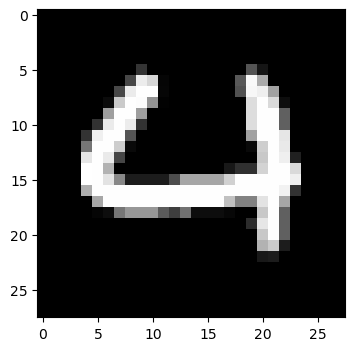

In [9]:
# Dataset visualization

N = 60 # index


# print(x_train[N])
print(f"Dataset size: {y_train.shape}")
print(f"Image shape: {x_train[N].shape} -  Label: {y_train[N]}")
plt.figure(figsize=(4,4))
plt.imshow(x_train[N], cmap='gray')

In [52]:
# Normalization
x_train_norm, x_test_norm = x_train/255, x_test/255

# width and height of the images
w = x_train_norm.shape[1]
h = x_train_norm.shape[2]

# classes
n_classes = 10

In [58]:
# Architecture definition

model = keras.Sequential([
    layers.Flatten(input_shape=(w,h)),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

print(x_train_norm.shape)
model.summary()


(60000, 28, 28)


/Users/denisegayet/env_tf/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,818 (858.66 KB)

 Trainable params: 219,818 (858.66 KB)

 Non-trainable params: 0 (0.00 B)

####  📝 Ejercicio: 

Cuál es la función de la capa *flatten*?

La función de la capa Flatten es la de aplanar el tensor de tamaño `(w,h)` en un tensor que sea de tamaño `(w*h,1)`, ya que la capa 1 toma vectores de una sola dimensión


In [ ]:
lr = 0.001
# op = Adam(lr)
op = SGD(lr)

# sparte_categorical_crossentropy se usa cuando los labels son senteros
# si son one-hot se utiliza categorical_crossentropy.
model.compile(loss='sparse_categorical_crossentropy', optimizer=op, metrics=['accuracy'])

In [61]:
# Training
epochs = 32
batch_size = 50
validation_split = 0.2

history = model.fit(x_train_norm, y_train, 
                    epochs=epochs, batch_size=batch_size, validation_split=validation_split)

Epoch 1/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2371 - loss: 2.1401 - val_accuracy: 0.3232 - val_loss: 1.9322
Epoch 2/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3322 - loss: 1.8955 - val_accuracy: 0.4363 - val_loss: 1.6922
Epoch 3/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4467 - loss: 1.6571 - val_accuracy: 0.5412 - val_loss: 1.4674
Epoch 4/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5403 - loss: 1.4480 - val_accuracy: 0.6257 - val_loss: 1.2670
Epoch 5/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6216 - loss: 1.2571 - val_accuracy: 0.6883 - val_loss: 1.0939
Epoch 6/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6820 - loss: 1.0972 - val_accuracy: 0.7354 - val_loss: 0.9517
Epoch 7/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7262 - loss: 0.9626 - val_accuracy: 0.7690 - val_loss: 0.8387
Epoch 8/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7589 - loss: 0.8585 - val_accuracy: 0.

In [56]:
# Model evaluation

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n Test accuracy: {test_acc:.4f}")
print(f"\n Test Loss: {test_loss:.4f}")

model.summary()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8836 - loss: 62.8754

 Test accuracy: 0.8988

 Test Loss: 57.2116


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,052 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

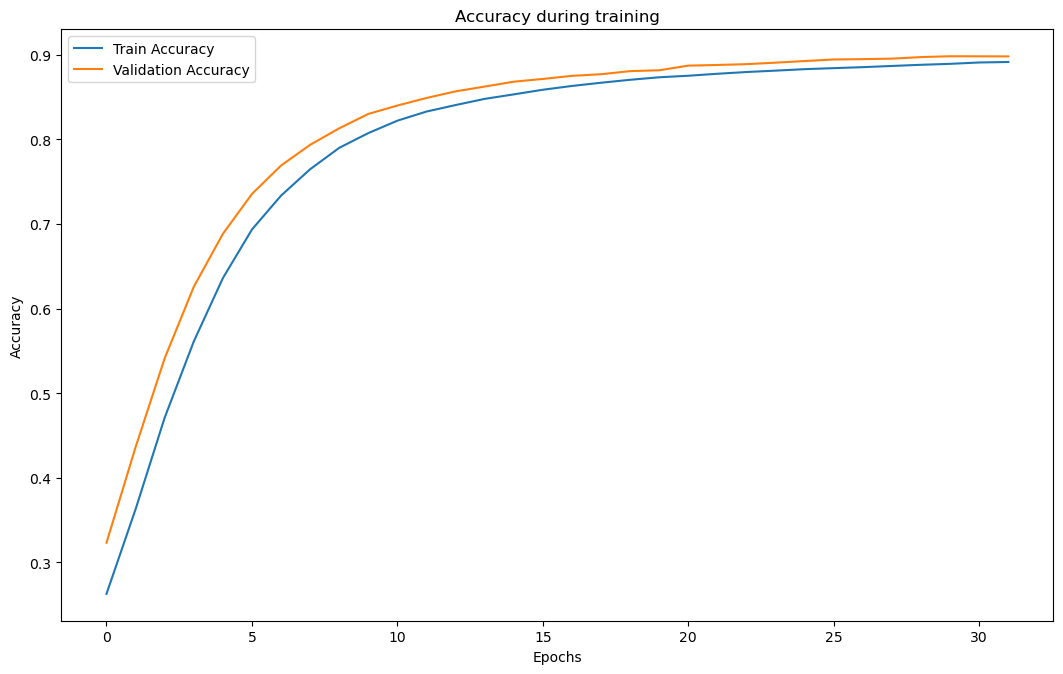

In [62]:
# Gráfico de accuracy over epochs
plt.figure(figsize=(5,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path + "_lr_00005_accuracy.png", bbox_inches='tight')
plt.show()

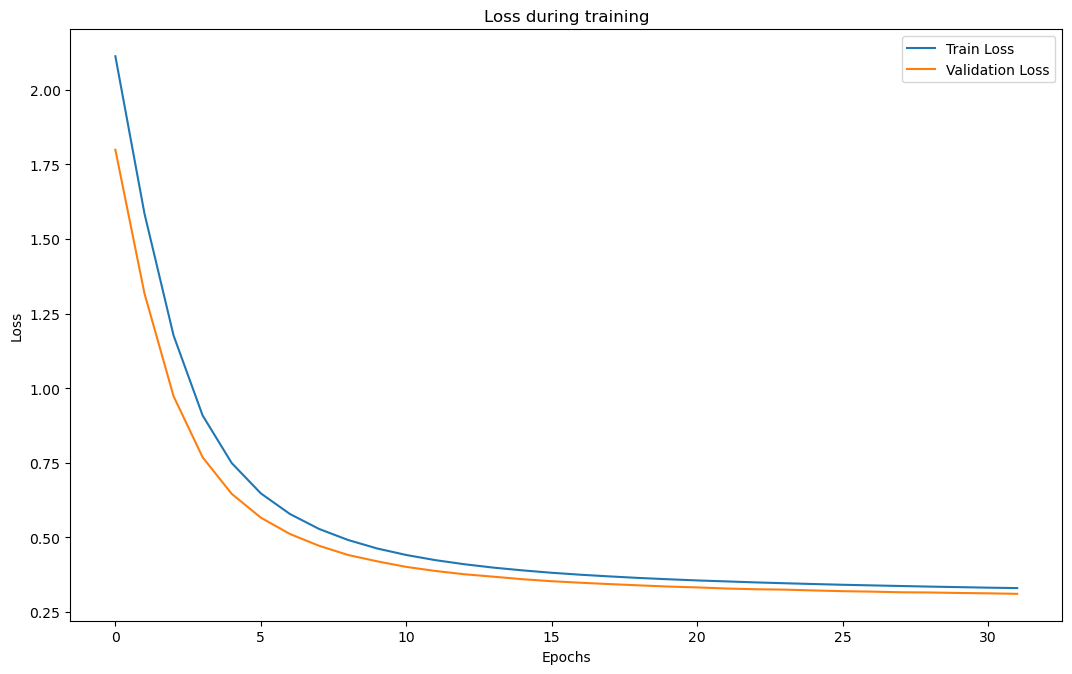

In [17]:
# Gráfico de loss over epochs
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path + "vanilla_model_loss.png", bbox_inches='tight')
plt.show()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted Class: 9 - True label: 9


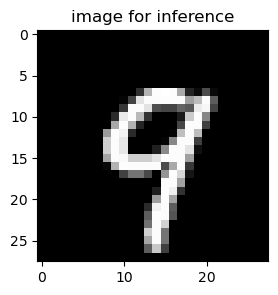

In [42]:
#inference test

index = 12
plt.figure(figsize=(3,3))
plt.imshow(x_test[index], cmap='gray')

plt.title("image for inference")

# hace las veces de flatten
#x_test_norm_reshaped = x_test_norm[index].reshape(-1,w*h)
y_pred = model.predict(x_test_norm)

y_pred = np.argmax(y_pred, axis=1) 
print(f"Predicted Class: {y_pred[index]} - True label: {y_test[index]}")

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score

y_pred = model.predict(x_test_norm)

y_pred_labels = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [54]:
# metrics

report_classification = classification_report(y_test, y_pred_labels, digits=4) #, output_dict=True
print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

with open('report.txt', 'w') as f:
    print('Accuracy avg     %.4f' % test_acc)  # Python 3.x

              precision    recall  f1-score   support

           0     0.9416    0.9704    0.9558       980
           1     0.9660    0.9753    0.9706      1135
           2     0.9232    0.8847    0.9035      1032
           3     0.8929    0.9079    0.9003      1010
           4     0.8932    0.9196    0.9062       982
           5     0.8890    0.8531    0.8707       892
           6     0.9315    0.9374    0.9344       958
           7     0.9301    0.9066    0.9182      1028
           8     0.8852    0.8871    0.8862       974
           9     0.8842    0.8930    0.8886      1009

    accuracy                         0.9147     10000
   macro avg     0.9137    0.9135    0.9135     10000
weighted avg     0.9147    0.9147    0.9145     10000

Accuracy avg     0.8977
Accuracy avg     0.8977


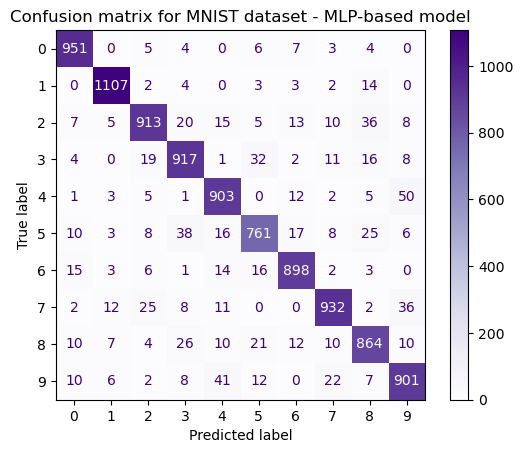

<Figure size 1280x768 with 0 Axes>

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for MNIST dataset - MLP-based model')
plt.show()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path + "vanilla_model_cm.png", bbox_inches='tight')
plt.show()
plt.show()

0.9526543353090461


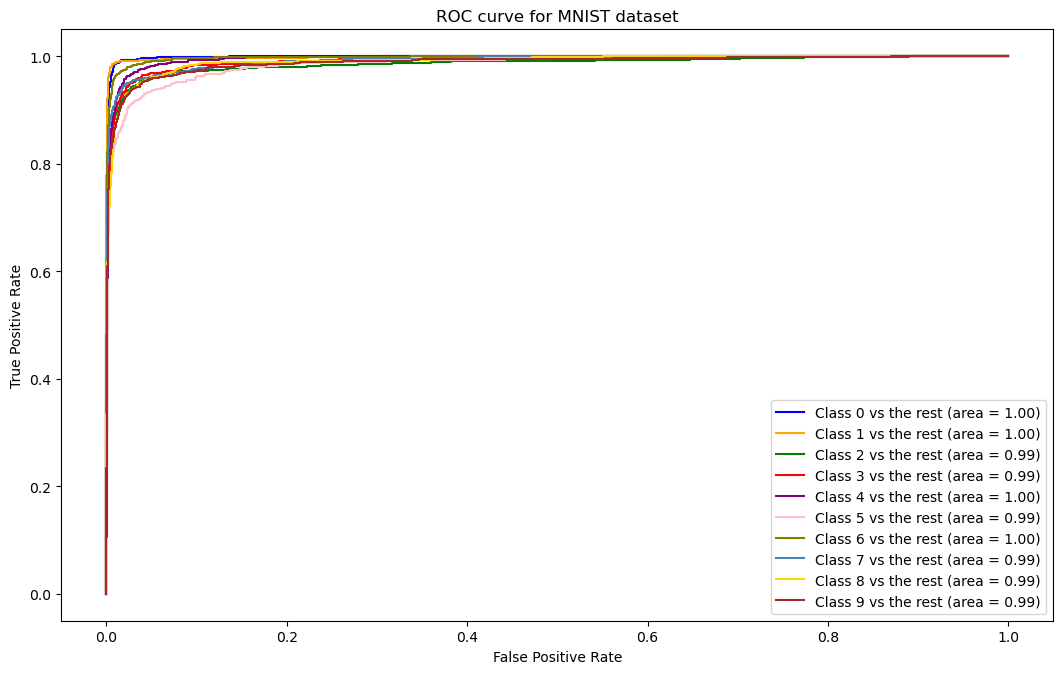

In [52]:
# ROC Curve
import matplotlib.colors as mcolors

# compute ROC curve and ROC area for each class

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
  fpr[i], tpr[i], _ = roc_curve(y_test, y_pred[:,i], pos_label=i) 
  roc_auc[i] = auc(fpr[i], tpr[i])

## roc_auc_score require the y_test and y_pred array be in catecorical mode
ycat_test = keras.utils.to_categorical(y_test, 10)
ycat_test_pred = keras.utils.to_categorical(y_pred_labels, 10)

print(roc_auc_score(ycat_test, ycat_test_pred, multi_class='ovr', average='weighted'))

# Plot with for-loop
color = ['blue','orange', 'green', 'red', 'purple', 'pink', 'olive', 'steelblue', 'gold', 'brown' ]
plt.figure(figsize=(15,5))
for g in range (10):
  plt.plot(fpr[g], tpr[g], color=color[g], label='Class %d vs the rest (area = %.2f)' % (g, roc_auc[g]))

# Plot by element
# plt.plot(fpr[0], tpr[0], color='blue', label='Class 0 vs the rest (area = %.2f)' % roc_auc[0])
# plt.plot(fpr[1], tpr[1], color='red', label='Class 1 vs the rest (area = %.2f)' % roc_auc[1])
# plt.plot(fpr[2], tpr[2], color='green', label='Class 2 vs the rest (area = %.2f)' % roc_auc[2])
# plt.plot(fpr[3], tpr[3], color='orange', label='Class 3 vs the rest (area = %.2f)' % roc_auc[3])

plt.title('ROC curve for MNIST dataset')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path + "vanilla_model_ROC.png", bbox_inches='tight')
plt.show()
plt.show()

In [ ]:
# saving model
model.save('./models/mnistModel_FC_vanilla.h5')

In [3]:
model = keras.Sequential([
    layers.Flatten(input_shape=(w,h)),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

lr = [0.001,0.0001,0.01]
acc_tr = []
acc_val = []

# Training
epochs = 32
batch_size = 50
validation_split = 0.2

plt.figure(figsize=(5,3))
for i in lr:
    op = SGD(i)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=op, metrics=['accuracy'])
    print(i)
    print(model.get_weights())
    model.fit(x_train_norm, y_train, 
          epochs=epochs, batch_size=batch_size, validation_split=validation_split)
    acc_tr.append(history.history['accuracy'])
    acc_val.append(history.history['val_accuracy'])
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


# Gráfico de accuracy over epochs
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
#plt.savefig(fig_path + "_biggest_model_accuracy.png", bbox_inches='tight')
plt.show()


NameError: name 'w' is not defined

####  📝 Ejercicio: 

Varíe el valor de batch, epoch, y learning rate. Obtenga las gráficas correspondientes. Qué conclusiones puede obtener al variar estos parámetros?


### Conclusiones

**variación del learning rate** lr_original = 0.001
- lr = 0.1: el modelo no converge. Los saltos son los suficientemente grandes como para que el movimiento no sea en dirección del máximo gradiente.
- lr = 0.0001: el modelo converge de manera mucho más lenta. Toma más epochs para llegar a la convergencia, dado que las actulizaciones de los pesos tienen un step más pequenio.

**variación del batchsize**
- aumentar el batchsize (a 200) aumenta la velocidad de cómputo (se propaga el gradiente menos veces por epoch) pero reduce el accuracy si la cantidad de epochs se mantiene. Para llegar a una convergencia se necesitan más epochs.

**variación de las epochs**

**variación de la profundidad de la red**
- agregar capas aumenta el accuracy pero también aumenta considerablemente el tiempo de cómputo.

## CIFAR-10 para CNN

In [22]:
import os
import numpy as np
from numpy import array

import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd


## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam

## Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [24]:
# loading dataset CIFAR-10

fig_path = './figs/CIFAR-10'

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

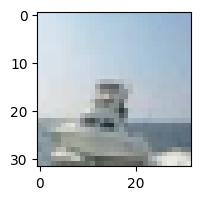

In [25]:
plt.figure(figsize=(2,2))

N = 100
plt.imshow(x_train[N])

In [26]:
x_train_norm, x_test_norm = x_train, x_test
x_train_norm.shape

(50000, 32, 32, 3)

In [28]:
# CNN model

model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)), 
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Reduce overfitting
    
    Dense(10, activation='softmax')
])

model.summary()

/Users/denisegayet/.venv_test/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# compile
hparams = {
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 32,
    "validation_split": 0.2
}

op = Adam(hparams['learning_rate'])
model.compile(optimizer=op,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train
history = model.fit(x_train, y_train, epochs=hparams['epochs'], 
                    batch_size=None, validation_split=hparams['validation_split'])

Epoch 1/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.2088 - loss: 3.5089 - val_accuracy: 0.4193 - val_loss: 1.6162
Epoch 2/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.3705 - loss: 1.6998 - val_accuracy: 0.4603 - val_loss: 1.4615
Epoch 3/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4517 - loss: 1.4983 - val_accuracy: 0.5112 - val_loss: 1.3452
Epoch 4/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5050 - loss: 1.3702 - val_accuracy: 0.5393 - val_loss: 1.2980
Epoch 5/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5298 - loss: 1.3055 - val_accuracy: 0.5716 - val_loss: 1.2192
Epoch 6/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5653 - loss: 1.2265 - val_accuracy: 0.6031 - val_loss: 1.1268
Epoch 7/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5872 - loss: 1.1616 - val_accuracy: 0.6174 - val_loss: 1.0897
Epoch 8/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6131 -

In [30]:
# test
test_loss, test_acc = model.evaluate(x_test_norm, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6631 - loss: 1.1784

Test Accuracy: 0.6620


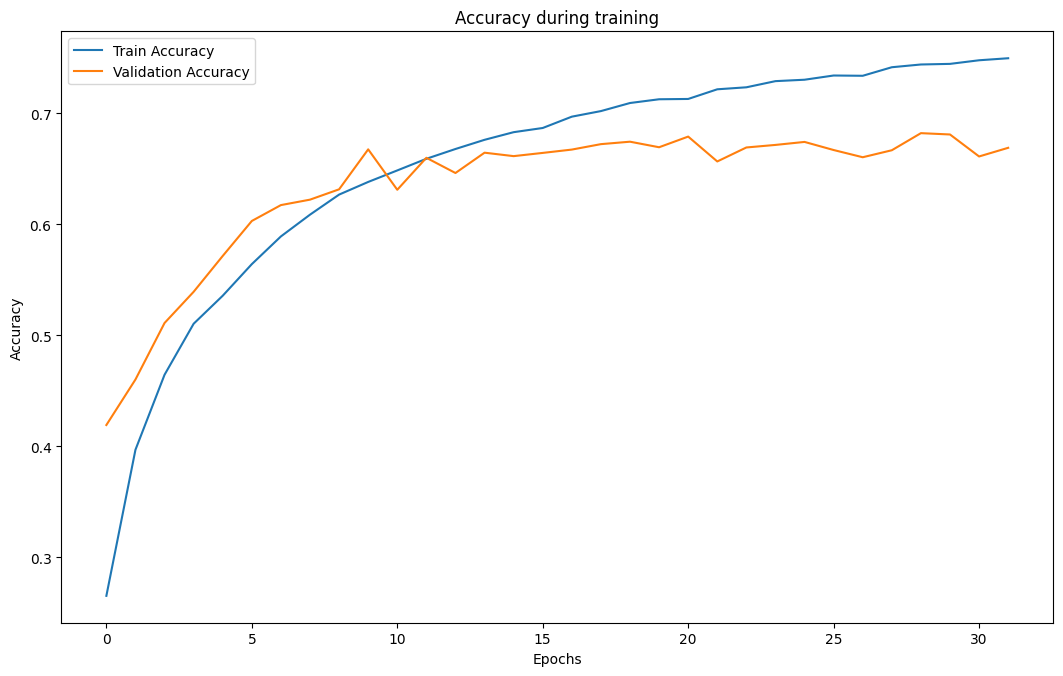

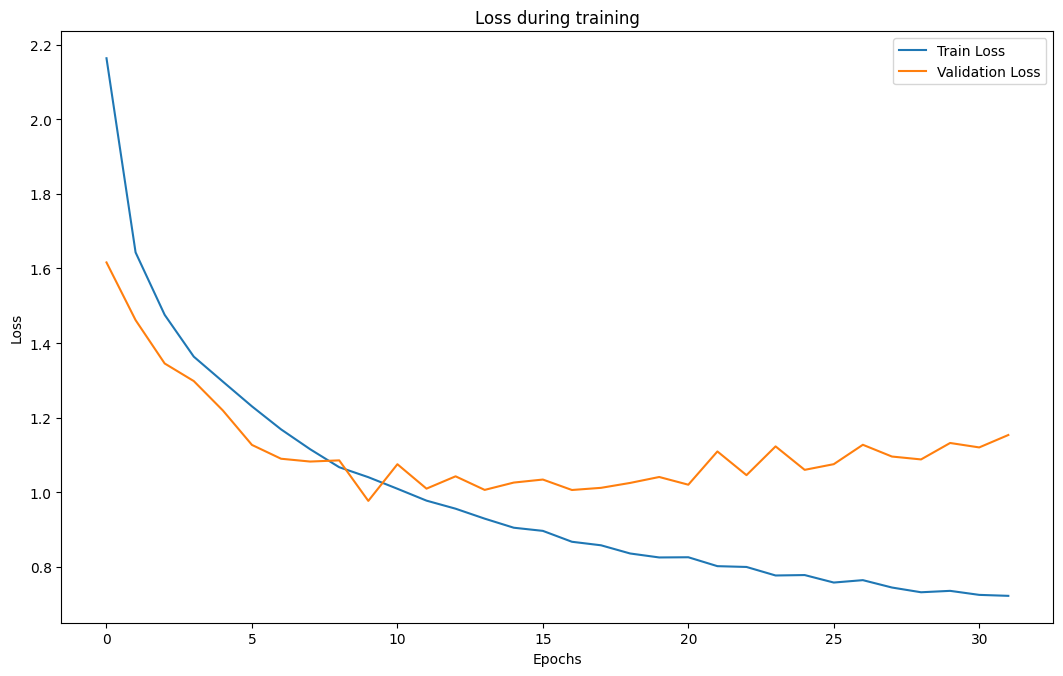

In [31]:
# Plot accuracy
plt.figure(figsize=(10,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
#plt.savefig(fig_path + "_vanilla_model_cnn_accuracy.png", bbox_inches='tight')
plt.show()

plt.show()


# Plot loss
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
#plt.savefig(fig_path + "_vanilla_model_cnn_loss.png", bbox_inches='tight')
plt.show()


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score


y_pred = model.predict(x_test_norm)
y_pred_labels = np.argmax(y_pred, axis=1)

report_classification = classification_report(y_test, y_pred_labels, digits=4) #, output_dict=True
print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0     0.7590    0.6520    0.7015      1000
           1     0.8180    0.7910    0.8043      1000
           2     0.6091    0.4830    0.5388      1000
           3     0.4374    0.4260    0.4316      1000
           4     0.5599    0.6400    0.5973      1000
           5     0.6250    0.5050    0.5586      1000
           6     0.6467    0.8200    0.7231      1000
           7     0.6678    0.7620    0.7118      1000
           8     0.7730    0.7830    0.7779      1000
           9     0.7331    0.7580    0.7453      1000

    accuracy                         0.6620     10000
   macro avg     0.6629    0.6620    0.6590     10000
weighted avg     0.6629    0.6620    0.6590     10000

Accuracy avg     0.6620


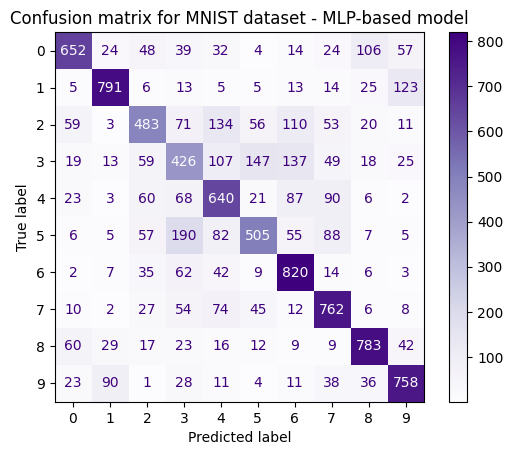

<Figure size 1280x768 with 0 Axes>

In [33]:
# Confusion matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for MNIST dataset - MLP-based model')
plt.show()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path + "_vanilla_model_cnn_cm.png", bbox_inches='tight')
plt.show()
plt.show()

### Conclusiones

- Agregar Capas:
- Agregar Dropout:
- Cambiar el Optimizer:


--------------

####  📝 Ejercicios: 


- Computar las métricas para CIFAR-10.

- Para MNIST, reemplazar la capa _Flatten_ en la definicion del modelo por _Dense_. Para este paso, la imagen se debe convertir en un vector de 1D. 

- Repetir el procedimiento anterior par fashion MNIST y CIFAR-100 datasets. 

- Obtener las métricas pertinentes para verificar el rendimiento del modelo.

- Para CIFAR-10 seleccione 2 clases e implemente un clasificador binario.

## Fashion MNIST


### Classes

| Label | Class |  
|-----------|-----------|
|0  | T-shirt/top	   |
|1	|Trouser    |
|2	|Pullover|
|3	|Dress|
|4	|Coat|
|5	|Sandal|
|6	|Shirt|
|7	|Sneaker|
|8	|Bag	|
|9	|Ankle boot|

In [ ]:
import os
import numpy as np
from numpy import array

import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd


## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.optimizers import SGD, Adam

## Datasets
from keras.datasets import cifar10
from keras.datasets import cifar100
from keras.datasets import mnist
from keras.datasets import fashion_mnist

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig_path="./figs/Fashion-MNIST"

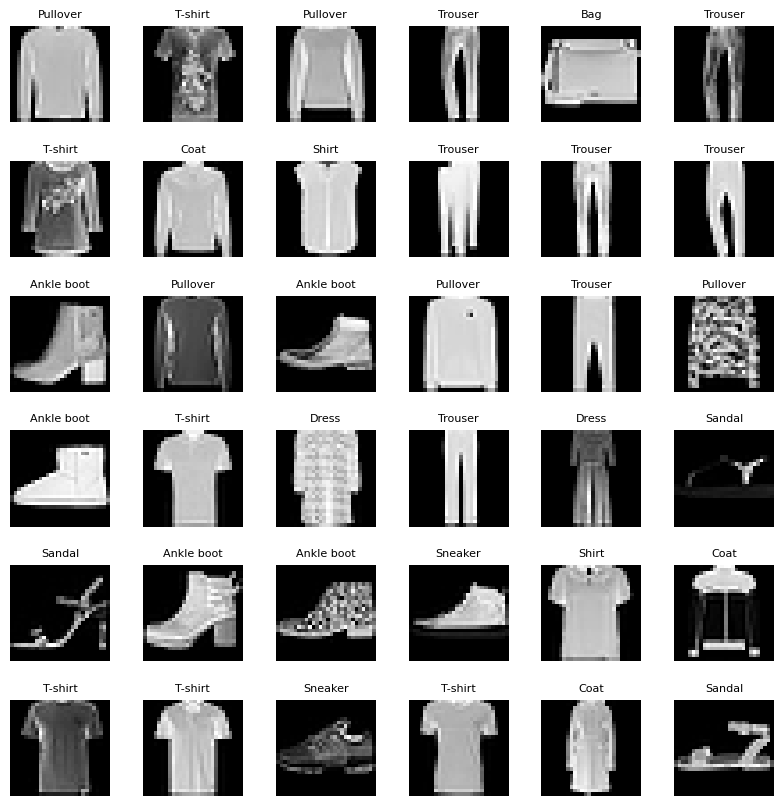

In [3]:
(x_train, y_train), (x_test,y_test) = fashion_mnist.load_data()
x_train_norm, x_test_norm = x_train/255, x_test/255

in_shape = (x_train[0].shape[0],x_train[0].shape[1],1)


labels = ['T-shirt',
          'Trouser',
          'Pullover',
          'Dress',
          'Coat',
          'Sandal',
          'Shirt',
          'Sneaker',
          'Bag',
          'Ankle boot']

# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train[index,1:], cmap='gray')
    label_index = int(y_train[index])
    axes[i].set_title(labels[label_index], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)


Input_shape: (28, 28, 1)

Dataset length: 60000


Text(0.5, 1.0, 'Class distribution in test set')

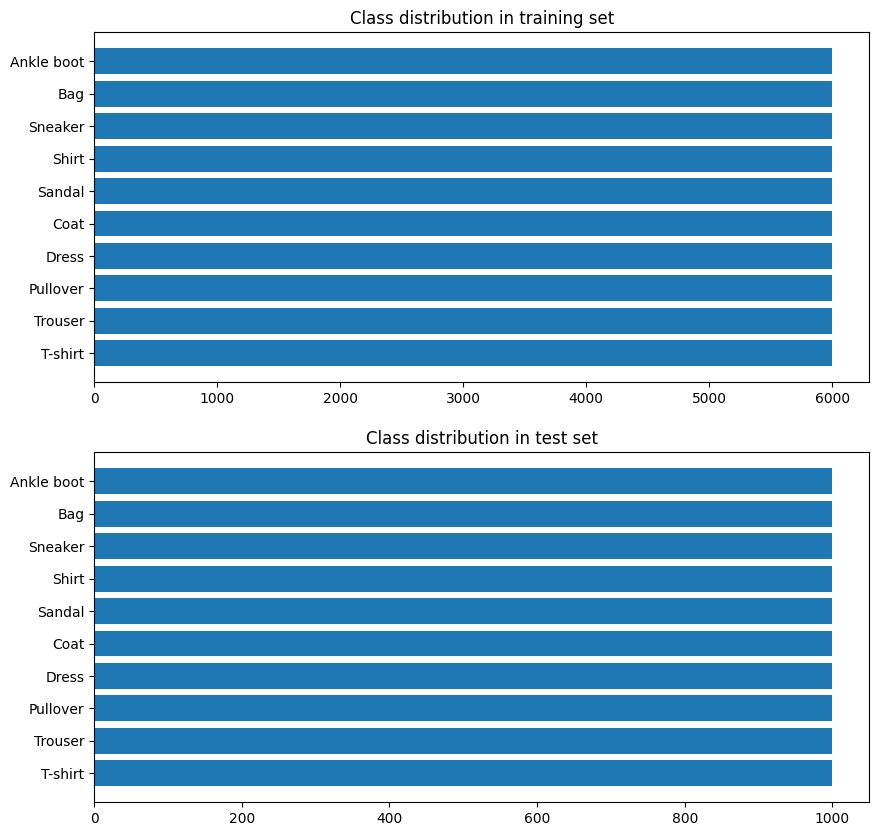

In [4]:
print(f"Input_shape: {in_shape}")
print(f"\nDataset length: {len(x_train)}")

fig, axes = plt.subplots(2, 1, figsize = (10,10))
axes = axes.ravel()

classes, counts = np.unique(y_train, return_counts=True)
axes[0].barh(labels, counts)
axes[0].set_title('Class distribution in training set')

classes, counts = np.unique(y_test, return_counts=True)
axes[1].barh(labels, counts)
axes[1].set_title('Class distribution in test set')


In [14]:
hparams = {
    'epochs' : 32,
    'learning_rate' : 0.001,
    'batch_size' : 50,
    'validation_split' : 0.2
}


model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=in_shape),
    #BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=in_shape),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    #BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(len(labels), activation='softmax')
])

op = Adam(hparams['learning_rate'])
model.compile(optimizer=op,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

/Users/denisegayet/.venv_test/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 442,922 (1.69 MB)

 Trainable params: 442,922 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(x_train_norm, y_train,
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch_size'],
                    validation_split=hparams['validation_split'])

Epoch 1/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 62s 64ms/step - accuracy: 0.6169 - loss: 1.0203 - val_accuracy: 0.8414 - val_loss: 0.4081
Epoch 2/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 79s 83ms/step - accuracy: 0.8539 - loss: 0.4130 - val_accuracy: 0.8806 - val_loss: 0.3333
Epoch 3/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 65s 67ms/step - accuracy: 0.8800 - loss: 0.3398 - val_accuracy: 0.9021 - val_loss: 0.2688
Epoch 4/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - accuracy: 0.8972 - loss: 0.2954 - val_accuracy: 0.9114 - val_loss: 0.2561
Epoch 5/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 65s 67ms/step - accuracy: 0.8985 - loss: 0.2811 - val_accuracy: 0.9117 - val_loss: 0.2371
Epoch 6/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step - accuracy: 0.9073 - loss: 0.2626 - val_accuracy: 0.9181 - val_loss: 0.2280
Epoch 7/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.9122 - loss: 0.2515 - val_accuracy: 0.9159 - val_loss: 0.2276
Epoch 8/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.9163 - loss: 0.2324 - 

In [16]:
fig_path="./figs/Fashion-MNIST/"
model_name = "FashionMNIST_CNN_6_Layers_DP"
model.save('./models/'+model_name+'.h5')
model.save('./models/'+model_name+'.keras')

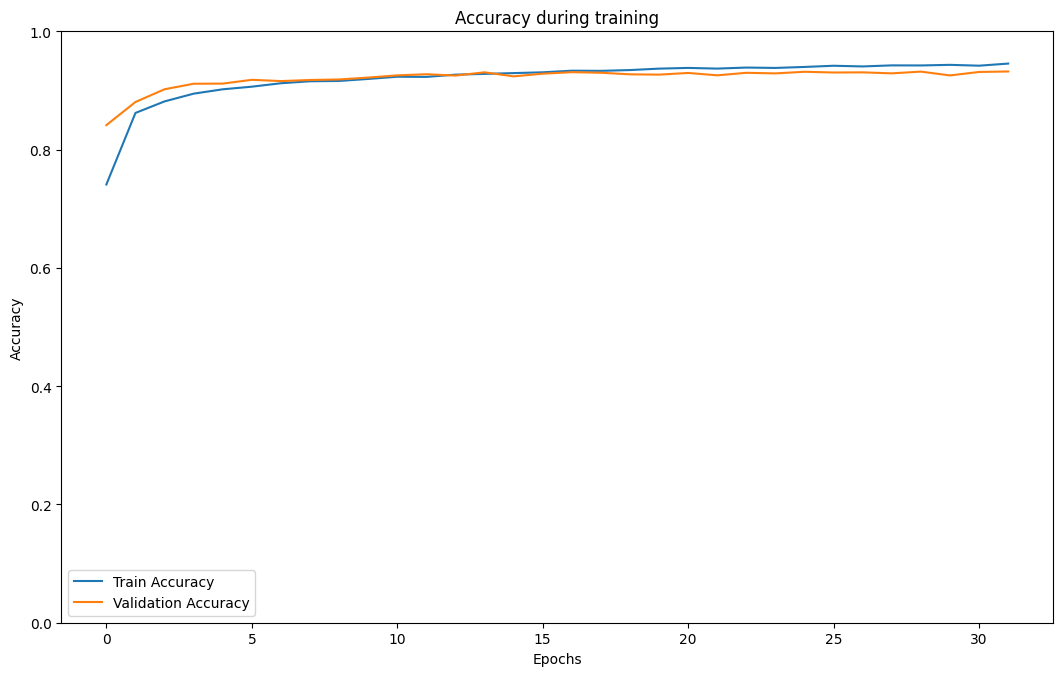

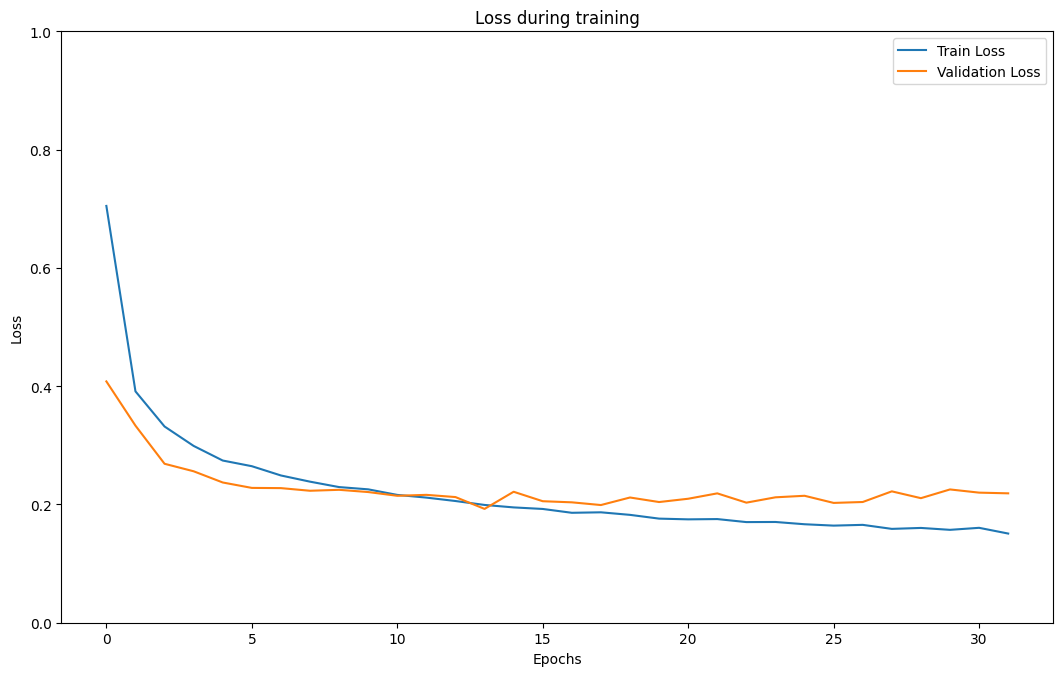

In [18]:
# Plot accuracy
plt.figure(figsize=(10,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Accuracy during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
#plt.savefig(fig_path+model_name+"_acc.png", bbox_inches='tight')
plt.show()

plt.show()


# Plot loss
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1)
plt.title('Loss during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
#plt.savefig(fig_path+model_name+"_loss.png", bbox_inches='tight')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6885 - loss: 77.0244
              precision    recall  f1-score   support

           0     0.8948    0.8510    0.8724      1000
           1     0.9920    0.9940    0.9930      1000
           2     0.9313    0.8670    0.8980      1000
           3     0.9323    0.9370    0.9347      1000
           4     0.8637    0.9060    0.8843      1000
           5     0.9899    0.9820    0.9859      1000
           6     0.7602    0.8050    0.7819      1000
           7     0.9711    0.9750    0.9731      1000
           8     0.9851    0.9890    0.9870      1000
           9     0.9741    0.9770    0.9755      1000

    accuracy                         0.9283     10000
   macro avg     0.9294    0.9283    0.9286     10000
weighted avg     0.9294    0.9283    0.9286     10000

Accuracy avg     0.6932


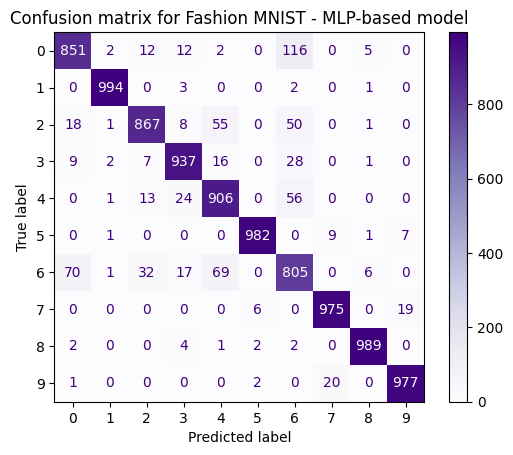

In [20]:
y_pred = model.predict(x_test_norm)
y_pred_labels = np.argmax(y_pred, axis=1)

test_loss, test_acc = model.evaluate(x_test, y_test)


report_classification = classification_report(y_test, y_pred_labels, digits=4) #, output_dict=True
print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for Fashion MNIST - MLP-based model')
plt.show()

## CIFAR-100

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

In [51]:
# normalization
x_train, x_test = x_train/255.0, x_test/255.0

[19]

Shape de las entradas: (32, 32, 3)

Cantidad de classes: 100

Dataset length: 50000


/var/folders/gb/t4c9wzf10mx4c9gy6736hjfw0000gn/T/ipykernel_72378/3612534369.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(y_train[index])


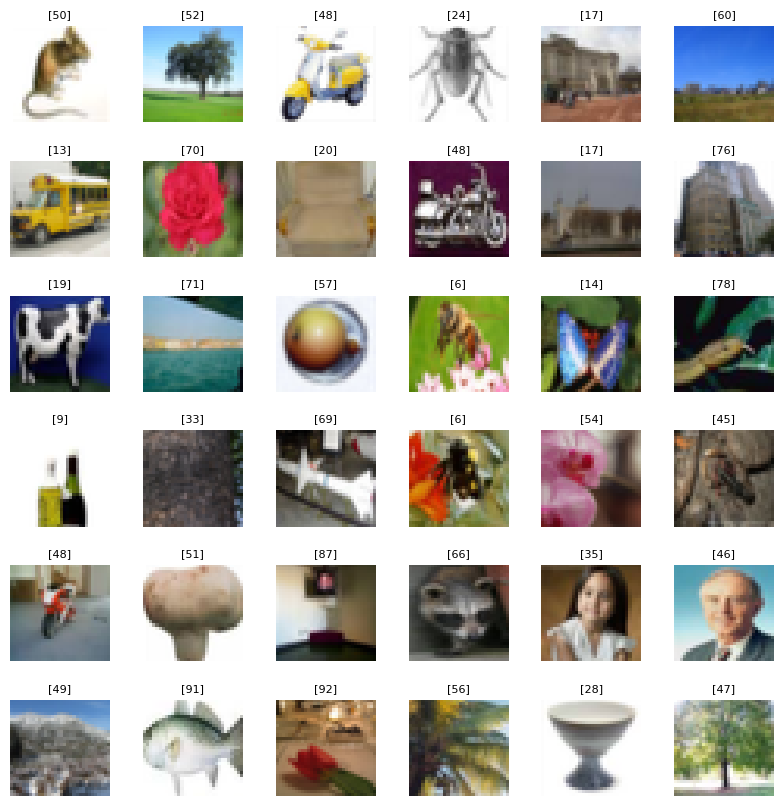

In [27]:
print(y_train[0])
n_classes = len(np.unique(y_train, return_counts=True)[0])
in_shape = (x_train[0].shape[0],x_train[0].shape[1],3)

# dataset visualization
print(f"\nShape de las entradas: {in_shape}")
print(f"\nCantidad de classes: {n_classes}")
print(f"\nDataset length: {len(x_train)}")



# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train[index,1:], cmap='gray')
    label_index = int(y_train[index])
    axes[i].set_title(y_train[index], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

Text(0.5, 1.0, 'Class distribution in test set')

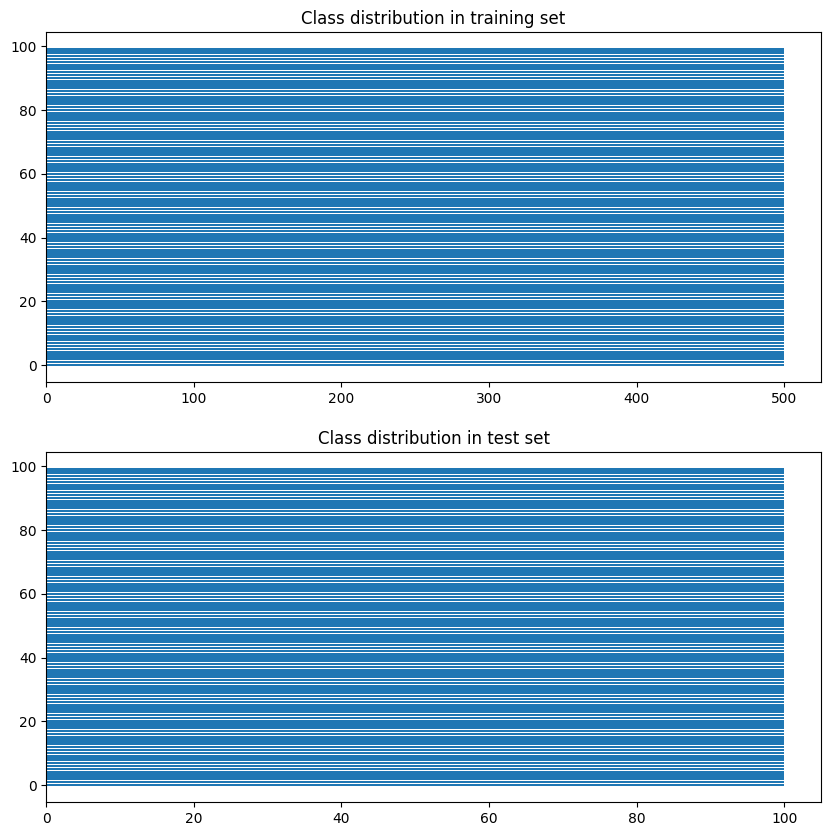

In [52]:
fig, axes = plt.subplots(2, 1, figsize = (10,10))
axes = axes.ravel()

classes, counts = np.unique(y_train, return_counts=True)
axes[0].barh(classes, counts)
axes[0].set_title('Class distribution in training set')

classes, counts = np.unique(y_test, return_counts=True)
axes[1].barh(classes, counts)
axes[1].set_title('Class distribution in test set')


In [61]:
# model definition
hparams={
    'epochs':32,
    'learning_rate':0.001,
    'batch_size':100,
    'validation_split':0.2
}

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=in_shape),
    MaxPooling2D((2,2)),
    Dropout(0.4),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.4),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),


    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

op = Adam(hparams['learning_rate'])
model.compile(optimizer=op,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

/Users/denisegayet/.venv_test/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,299,364 (4.96 MB)

 Trainable params: 1,299,364 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
fig_path="./figs/CIFAR-100/"
model_name = "CIFAR_100_CNN_3L_FC_2L_DP_MP"
model.save('./models/'+model_name+'.h5')
model.save('./models/'+model_name+'.keras')

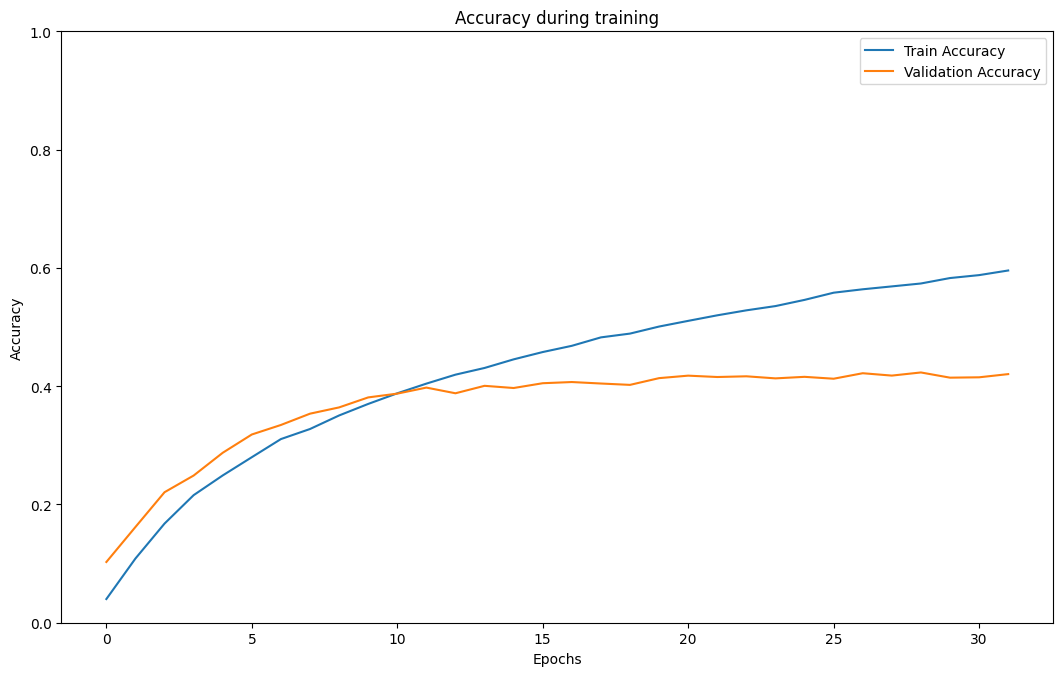

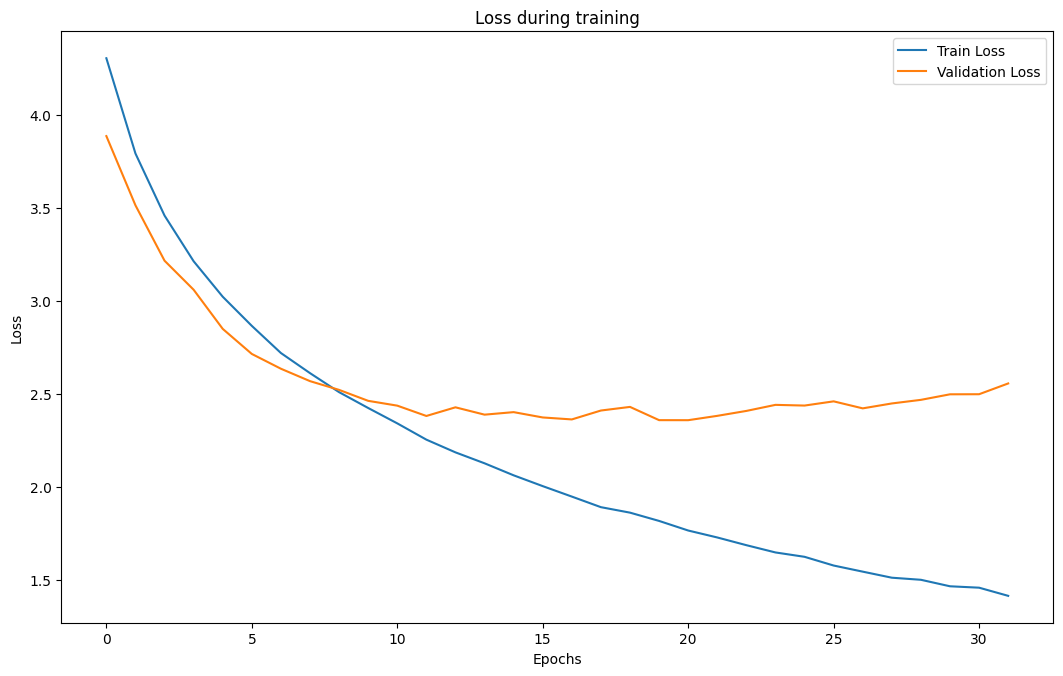

In [ ]:
# Plot accuracy
plt.figure(figsize=(10,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Accuracy during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path+model_name+"_acc.png", bbox_inches='tight')
plt.show()

plt.show()


# Plot loss
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path+model_name+"_loss.png", bbox_inches='tight')
plt.show()

In [60]:
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)

test_loss, test_acc = model.evaluate(x_test, y_test)


report_classification = classification_report(y_test, y_pred_labels, digits=4) #, output_dict=True
print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4248 - loss: 2.5130
              precision    recall  f1-score   support

           0     0.6198    0.7500    0.6787       100
           1     0.3878    0.5700    0.4615       100
           2     0.3238    0.3400    0.3317       100
           3     0.1772    0.1400    0.1564       100
           4     0.2404    0.2500    0.2451       100
           5     0.4861    0.3500    0.4070       100
           6     0.4127    0.5200    0.4602       100
           7     0.4425    0.5000    0.4695       100
           8     0.5392    0.5500    0.5446       100
           9     0.6024    0.5000    0.5464       100
          10     0.3333    0.3000    0.3158       100
          11     0.2973    0.1100    0.1606       100
          12     0.5541    0.4100    0.4713       100
          13     0.4571    0.1600    0.2370       100
          14     0.3516    0.3200    0.3351       100
          15     0.

## CIFAR-10 Binario

In [84]:
# dataset loading
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = [0,3]
n_classes=len(classes)
index_bin = np.where((y_train == classes[0]) | (y_train == classes[1]))

x_train_bin = x_train[index_bin[0]]
y_train_bin = y_train[index_bin[0]]

index_bin = np.where((y_test == classes[0]) | (y_test == classes[1]))

x_test_bin = x_test[index_bin[0]]
y_test_bin = y_test[index_bin[0]]


x_train_bin.shape

## replace every value of 3 with 1 so it can be binary
y_train_bin[y_train_bin==3] = 1
y_test_bin[y_test_bin==3] = 1

y_train_bin

array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [0]], dtype=uint8)


 Dataset input shape: (32, 32, 3)

 Dataset length: 10000


/var/folders/gb/t4c9wzf10mx4c9gy6736hjfw0000gn/T/ipykernel_72378/842566363.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(y_train_bin[index])


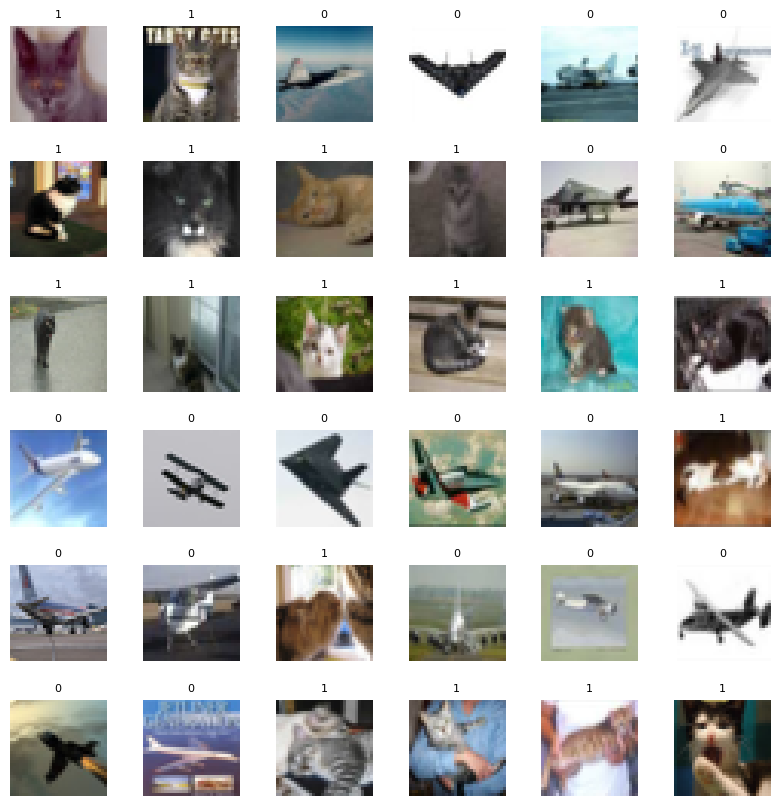

In [85]:
# data visualization
print(f"\n Dataset input shape: {x_train_bin[0].shape}")
print(f"\n Dataset length: {len(x_train_bin)}")

in_shape = (x_train_bin[0].shape[0], x_train_bin[0].shape[1], x_train_bin[0].shape[2])

# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train_bin) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train_bin[index])
    label_index = int(y_train_bin[index])
    axes[i].set_title(label_index, fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)


Text(0.5, 1.0, 'Class distribution in test set')

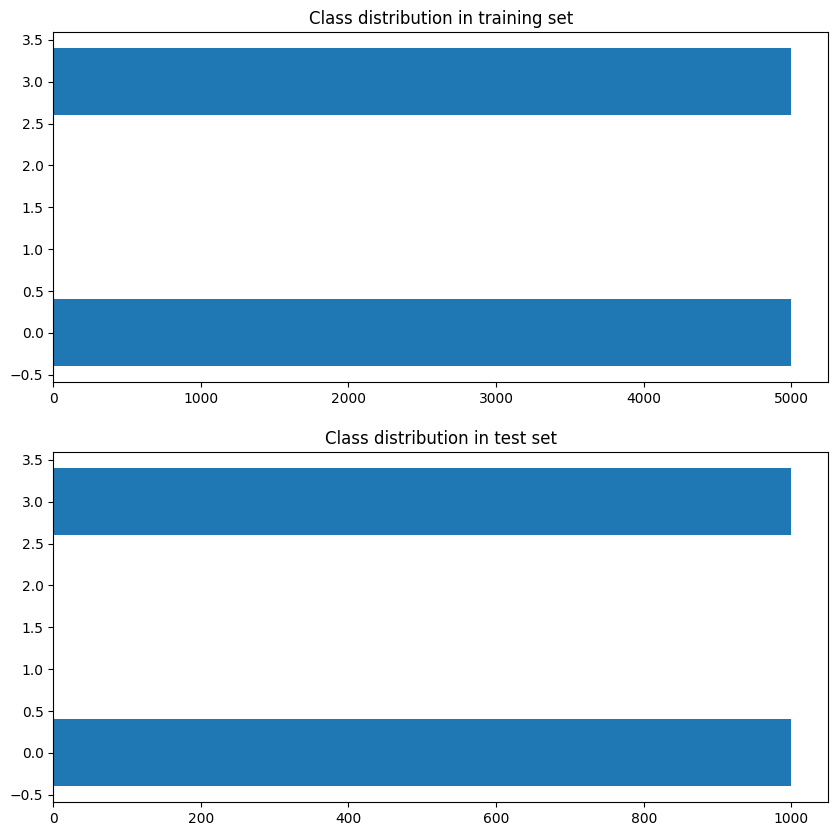

In [74]:
fig, axes = plt.subplots(2, 1, figsize = (10,10))
axes = axes.ravel()

classes, counts = np.unique(y_train_bin, return_counts=True)
axes[0].barh(classes, counts)
axes[0].set_title('Class distribution in training set')

classes, counts = np.unique(y_test_bin, return_counts=True)
axes[1].barh(classes, counts)
axes[1].set_title('Class distribution in test set')

In [86]:
# model definition
hparams={
    'epochs':32,
    'learning_rate':0.001,
    'batch_size':50,
    'validation_split':0.2
}

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=in_shape),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='sigmoid')
])

op = Adam(hparams['learning_rate'])
model.compile(optimizer=op,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

/Users/denisegayet/.venv_test/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,778 (1.36 MB)

 Trainable params: 355,778 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
history = model.fit(x_train_bin, y_train_bin,
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch_size'],
                    validation_split=hparams['validation_split'])

fig_path="./figs/CIFAR-10_bin/"
model_name = "CIFAR_10_bin_CNN_3_Layers"
model.save('./models/'+model_name+'.h5')
model.save('./models/'+model_name+'.keras')

Epoch 1/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7322 - loss: 8.3661 - val_accuracy: 0.8835 - val_loss: 0.2992
Epoch 2/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8922 - loss: 0.2743 - val_accuracy: 0.8935 - val_loss: 0.2677
Epoch 3/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9070 - loss: 0.2292 - val_accuracy: 0.9120 - val_loss: 0.2256
Epoch 4/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9157 - loss: 0.2070 - val_accuracy: 0.9185 - val_loss: 0.2118
Epoch 5/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9321 - loss: 0.1737 - val_accuracy: 0.9185 - val_loss: 0.2099
Epoch 6/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9331 - loss: 0.1513 - val_accuracy: 0.9105 - val_loss: 0.2535
Epoch 7/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9485 - loss: 0.1373 - val_accuracy: 0.9145 - val_loss: 0.2176
Epoch 8/32
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9512 - loss: 0.1187 - val_accu

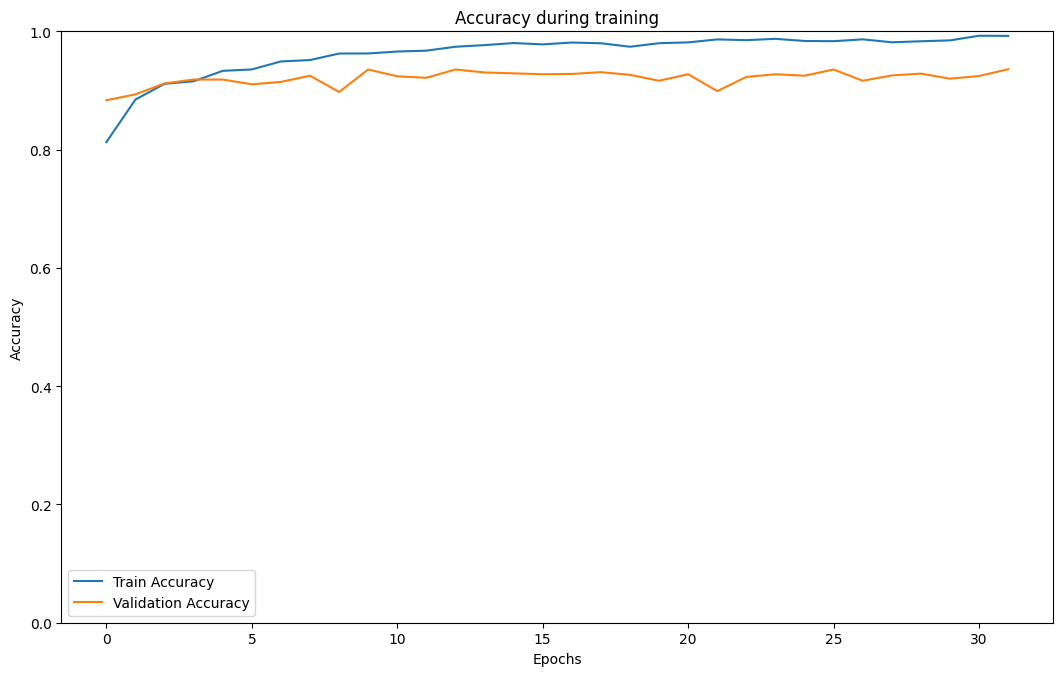

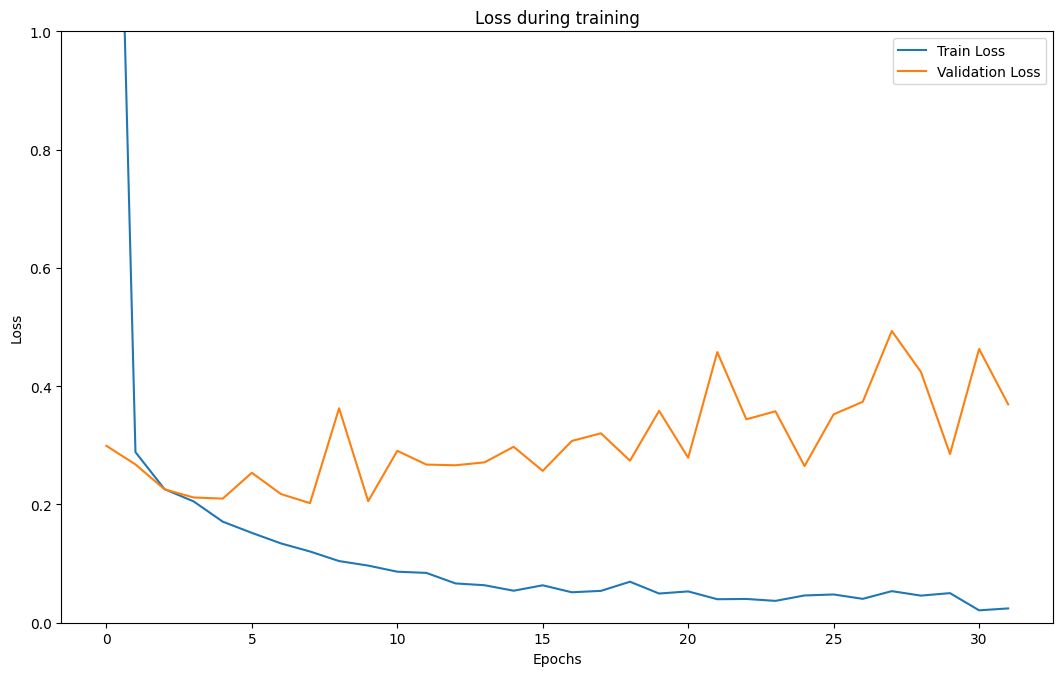

In [89]:
# Plot accuracy
plt.figure(figsize=(10,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Accuracy during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path+model_name+"_acc.png", bbox_inches='tight')
plt.show()

plt.show()


# Plot loss
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1)
plt.title('Loss during training')
plt.legend()


fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.savefig(fig_path+model_name+"_loss.png", bbox_inches='tight')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9273 - loss: 0.4112
              precision    recall  f1-score   support

           0     0.9367    0.9180    0.9273      1000
           1     0.9196    0.9380    0.9287      1000

    accuracy                         0.9280      2000
   macro avg     0.9282    0.9280    0.9280      2000
weighted avg     0.9282    0.9280    0.9280      2000

Accuracy avg     0.9280


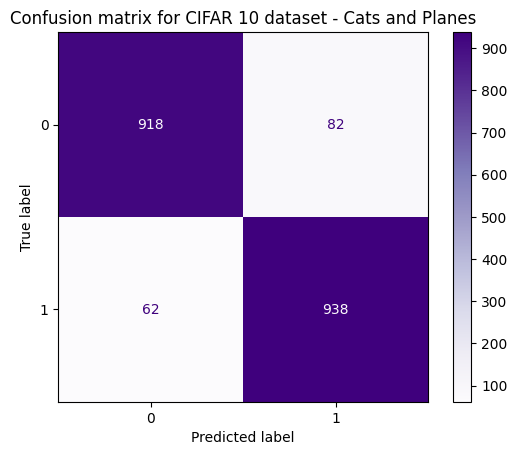

In [96]:
y_pred = model.predict(x_test_bin)
y_pred_labels = np.argmax(y_pred, axis=1)

test_loss, test_acc = model.evaluate(x_test_bin, y_test_bin)


report_classification = classification_report(y_test_bin, y_pred_labels, digits=4) #, output_dict=True
print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_test_bin, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for CIFAR 10 dataset - Cats and Planes')
plt.show()